## Loading Important Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

## Part A — Data preparation 
### 1. Load both datasets and document: 
- number of rows/columns 
- missing values / duplicates

In [15]:
trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print("=== TRADER DATA ===")
print(f"Table Structure: {trades.info()}")
print(f"\nRows: {trades.shape[0]:,} | Columns: {trades.shape[1]}")
print(f"\nMissing values:\n{trades.isnull().sum()}")
print(f"\nDuplicate rows: {trades.duplicated().sum()}")

print("\n=== FEAR/GREED DATA ===")
print(f"Table Structure: {fg.info()}")
print(f"\nRows: {fg.shape[0]:,} | Columns: {fg.shape[1]}")
print(f"\nMissing values:\n{fg.isnull().sum()}")
print(f"\nDuplicate rows: {fg.duplicated().sum()}")

=== TRADER DATA ===
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1),

### 2. Convert timestamps and align the datasets by date

In [32]:
# Trader data has "02-12-2024 22:50" format -->  parse it
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['datetime'].dt.date  # extract just the date part

# Fear/Greed already has a 'date' column as string --> parse it
fg['date'] = pd.to_datetime(fg['date']).dt.date

print(f"Trades date range: {trades['date'].min()} to {trades['date'].max()}")
print(f"Fear/Greed index date range: {fg['date'].min()} to {fg['date'].max()}")

# Simplify sentiment: group 5 labels into 2 (Fear vs Greed) for cleaner analysis
fg['sentiment'] = fg['classification'].map({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

#parse dates
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

# Simplify sentiment: group 5 labels into 2 (Fear vs Greed) for cleaner analysis
fg['sentiment'] = fg['classification'].map({
    'Extreme Fear': 'Fear', 'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed'
})

#merge table on date (daily basis)
trades_merged = trades.merge(fg[['date', 'classification', 'sentiment', 'value']], 
                              on='date', how='inner')

print(f"\nRows after merge: {trades_merged.shape[0]:,}")
print(f"\nSentiment distribution:\n{trades_merged['sentiment'].value_counts()}\n")

print(trades_merged.head())

Trades date range: 2023-05-01 to 2025-05-01
Fear/Greed index date range: 2018-02-01 to 2025-05-02

Rows after merge: 211,218

Sentiment distribution:
sentiment
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142

### 3. Key metrics: 
- daily PnL per trader (or per account) 
- number of trades per account
- win rate
- total volume
- average trade size 
- leverage distribution 
- number of trades per day per account
- long/short ratio
- max loss

In [ ]:
#Trades_table where every metric already has sentiment context
daily_trader_metrics = trades_merged.groupby(['Account', 'date', 'sentiment', 'classification', 'value']).agg(
    total_pnl    = ('Closed PnL', 'sum'),
    num_trades   = ('Trade ID', 'count'),
    avg_size_usd = ('Size USD', 'mean'),
    total_volume = ('Size USD', 'sum'),
    num_wins     = ('Closed PnL', lambda x: (x > 0).sum()),
    num_losses   = ('Closed PnL', lambda x: (x < 0).sum()),
    long_trades  = ('Direction', lambda x: (x == 'Open Long').sum()),
    short_trades = ('Direction', lambda x: (x == 'Open Short').sum()),
    max_loss     = ('Closed PnL', 'min'),
).reset_index()

# --- Derived metrics ---
daily_trader_metrics['win_rate']       = daily_trader_metrics['num_wins'] / daily_trader_metrics['num_trades']
daily_trader_metrics['long_ratio']     = daily_trader_metrics['long_trades'] / (daily_trader_metrics['long_trades'] + daily_trader_metrics['short_trades'])
daily_trader_metrics['short_ratio']     = daily_trader_metrics['short_trades'] / (daily_trader_metrics['long_trades'] + daily_trader_metrics['short_trades'])
daily_trader_metrics['drawdown_proxy'] = daily_trader_metrics['max_loss'].clip(upper=0).abs()

# leverage proxy: avg position size relative to median (since no leverage column exists)
median_size = daily_trader_metrics['avg_size_usd'].median()
daily_trader_metrics['leverage_proxy'] = daily_trader_metrics['avg_size_usd'] / median_size

print(f"Key Metrics table")
print(f"\nRows: {daily_trader_metrics.shape[0]:,} | Columns: {daily_trader_metrics.shape[1]}")
print(daily_trader_metrics.head())


Rows: 2,340 | Columns: 19
                                      Account        date sentiment  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11     Greed   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17     Greed   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18     Greed   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22     Greed   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     Greed   

  classification  value  total_pnl  num_trades  avg_size_usd  total_volume  \
0  Extreme Greed     76        0.0         177   5089.718249     900880.13   
1  Extreme Greed     90        0.0          68   7976.664412     542413.18   
2  Extreme Greed     83        0.0          40  23734.500000     949380.00   
3  Extreme Greed     94   -21227.0          12  28186.666667     338240.00   
4  Extreme Greed     79     1603.1          27  17248.148148     465700.00   

   num_wins  num_losses  long_trades  short_trades     max_loss  win_rate  \


## Part B — Analysis
### 1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
- PnL is actually higher on Fear days but p = 0.45, meaning the difference is not statistically significant. You cannot confidently say sentiment drives PnL. The win rate is similar on Fear and Greed days as well. What IS significant is that drawdown is 41% larger on Fear days, meaning more volatile/risky outcomes even if average PnL looks similar.

In [ ]:
from scipy import stats

#removing neutral sentiment rows 
fvg = daily_trader_metrics[daily_trader_metrics['sentiment'].isin(['Fear', 'Greed'])]

perf = fvg.groupby('sentiment')[['total_pnl', 'win_rate', 'drawdown_proxy']].mean().round(4)
print(perf)

# Statistical significance test
t, p = stats.ttest_ind(
    fvg[fvg['sentiment'] == 'Fear']['total_pnl'],
    fvg[fvg['sentiment'] == 'Greed']['total_pnl']
)
print(f"\nPnL t-test p-value: {p:.4f} — {'significant' if p < 0.05 else 'NOT significant'}")

           total_pnl  win_rate  drawdown_proxy
sentiment                                     
Fear       5185.1464    0.3571        462.4988
Greed      4144.2083    0.3627        328.4978

PnL t-test p-value: 0.4518 — NOT significant


### 2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)? 
- This is the most striking finding. On Fear days, traders trade 37% more frequently (p = 0.002, highly significant), use 43% larger positions, and are more bullish (higher long ratio). This is counter-intuitive — fear doesn't make traders cautious here, it makes them more active and aggressive.

In [39]:
behavior = fvg.groupby('sentiment')[['num_trades', 'avg_size_usd', 'long_ratio', 'total_volume']].mean().round(2)
print(behavior)

# Test whether trade frequency difference is significant
t, p = stats.ttest_ind(
    fvg[fvg['sentiment'] == 'Fear']['num_trades'],
    fvg[fvg['sentiment'] == 'Greed']['num_trades']
)
print(f"\nTrade frequency t-test p-value: {p:.4f} — {'significant' if p < 0.05 else 'NOT significant'}")

           num_trades  avg_size_usd  long_ratio  total_volume
sentiment                                                    
Fear           105.36       8529.86        0.57     756720.32
Greed           76.91       5954.63        0.47     351829.35

Trade frequency t-test p-value: 0.0020 — significant


## 3. Identify 2–3 segments : 
- high leverage vs low leverage traders 
- frequent vs infrequent traders 
- consistent winners vs inconsistent traders

### Resulting segments: 
- 11 high size, 11 low size, 10 mid size traders
- 16 frequent, 16 non-frequent traders
- 15 Consistent Winners, 14 Inconsistent, 3 Losers across 32 unique traders.

In [43]:
trader_summary = daily_trader_metrics.groupby('Account').agg(
    total_pnl      = ('total_pnl', 'sum'),
    avg_win_rate   = ('win_rate', 'mean'),
    avg_trades_day = ('num_trades', 'mean'),
    avg_size_usd   = ('avg_size_usd', 'mean'),
).reset_index()

# Segment 1: Position size (leverage proxy)
trader_summary['size_segment'] = pd.qcut(
    trader_summary['avg_size_usd'], q=3, 
    labels=['Low Size', 'Mid Size', 'High Size']
)
print(trader_summary['size_segment'].value_counts())

# Segment 2: Trade frequency
trader_summary['freq_segment'] = pd.qcut(
    trader_summary['avg_trades_day'], q=2, 
    labels=['Infrequent', 'Frequent']
)
print("\n", trader_summary['freq_segment'].value_counts())

# Segment 3: Performance archetype
def classify(row):
    if row['total_pnl'] > 0 and row['avg_win_rate'] >= 0.35:
        return 'Consistent Winner'
    elif row['total_pnl'] < 0:
        return 'Loser'
    else:
        return 'Inconsistent'

trader_summary['perf_segment'] = trader_summary.apply(classify, axis=1)
print("\n", trader_summary['perf_segment'].value_counts())

fvg = fvg.merge(
    trader_summary[['Account', 'size_segment', 'freq_segment', 'perf_segment']], 
    on='Account', how='left'
)

size_segment
Low Size     11
High Size    11
Mid Size     10
Name: count, dtype: int64

 freq_segment
Infrequent    16
Frequent      16
Name: count, dtype: int64

 perf_segment
Consistent Winner    15
Inconsistent         14
Loser                 3
Name: count, dtype: int64


## Visualizations 
### - PnL by size segment × sentiment
High-size traders flip their edge depending on sentiment. High Size traders earn $9,847/day on Fear days but only $2,640 on Greed days. Low Size traders do the opposite ($599 Fear, $2,910 Greed). Big position traders have a Fear-day edge; small position traders have a Greed-day edge.

### - Win rate + Long ratio by performance segment × sentiment
Consistent Winners stay bullish on Fear days, Losers don't. Winners have a long ratio of 0.605 on Fear days (vs 0.478 on Greed), meaning they buy the dip. Losers have a long ratio of only 0.177 on Fear — they short the fear, which loses money. This is the clearest behavioral difference between winning and losing traders.

### - Drawdown by frequency segment × sentiment
Frequent traders take 29% larger drawdowns on Fear days. Frequent traders average $613 drawdown on Fear vs $474 on Greed. Combined with the higher trade volume on Fear days, this suggests overtrading during fear is a significant risk driver.

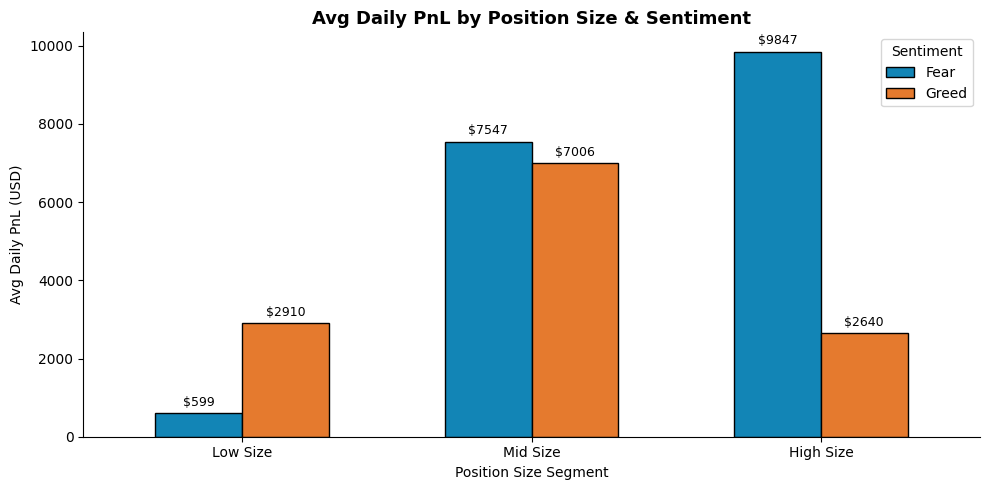

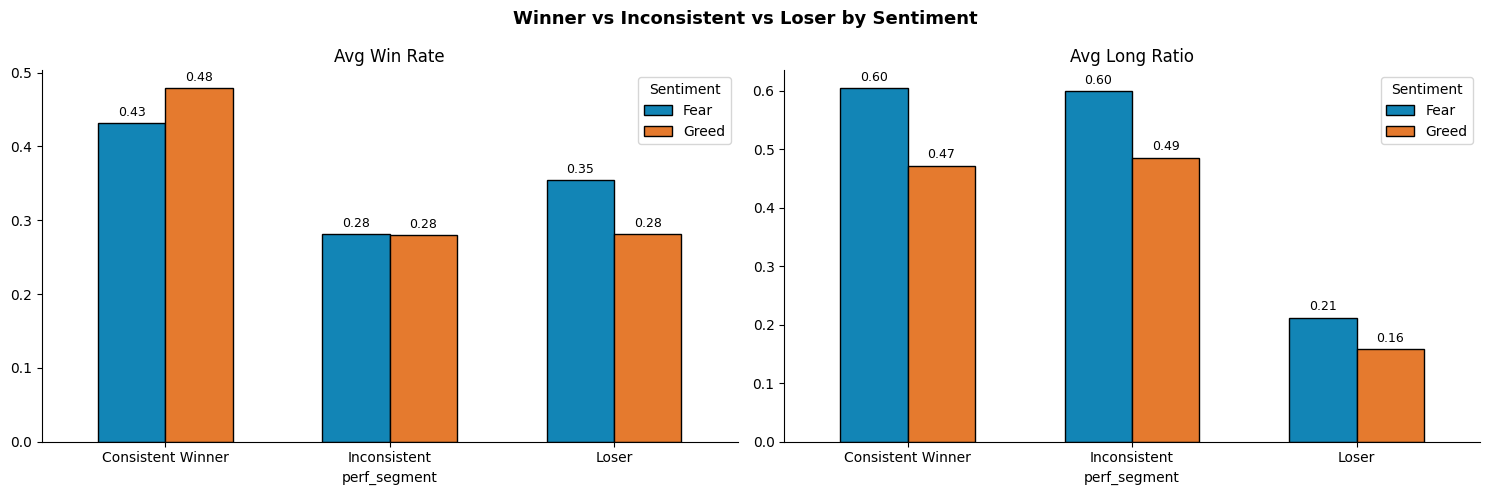

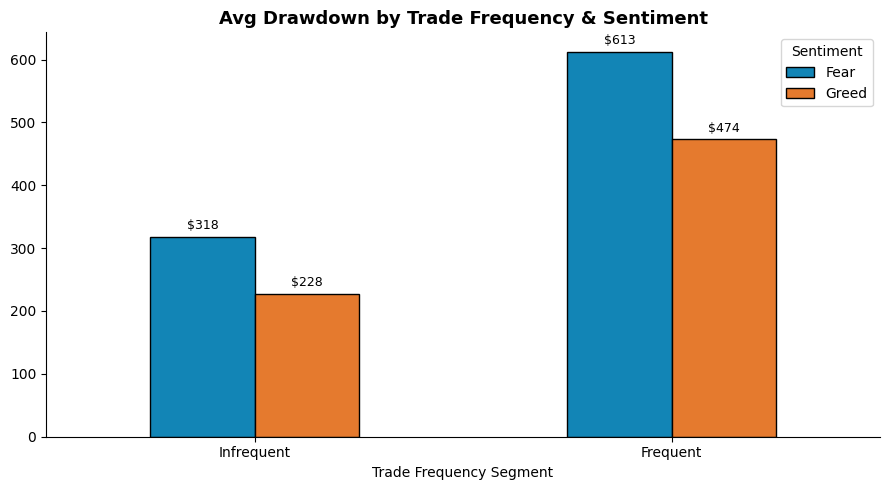

In [46]:
# PnL by size segment × sentiment
COLORS = {'Fear': "#1285b6", 'Greed': "#e57a2e"}

seg_pnl = fvg.groupby(['size_segment', 'sentiment'])['total_pnl'].mean().unstack()
ax = seg_pnl.plot(kind='bar', figsize=(10, 5),
                  color=[COLORS['Fear'], COLORS['Greed']],
                  edgecolor='black', width=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3, fontsize=9)
plt.title('Avg Daily PnL by Position Size & Sentiment', fontsize=13, fontweight='bold')
plt.xlabel('Position Size Segment')
plt.ylabel('Avg Daily PnL (USD)')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('chart3_pnl_size_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# Win rate + Long ratio by performance segment × sentiment
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, label in zip(axes,
                           ['win_rate', 'long_ratio'],
                           ['Avg Win Rate', 'Avg Long Ratio']):
    data = fvg.groupby(['perf_segment', 'sentiment'])[col].mean().unstack()
    data.plot(kind='bar', ax=ax,
              color=[COLORS['Fear'], COLORS['Greed']],
              edgecolor='black', width=0.6)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(label)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Sentiment')
plt.suptitle('Winner vs Inconsistent vs Loser by Sentiment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_winrate_longratio_perf_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# Drawdown by frequency segment × sentiment
dd = fvg.groupby(['freq_segment', 'sentiment'])['drawdown_proxy'].mean().unstack()
ax = dd.plot(kind='bar', figsize=(9, 5),
             color=[COLORS['Fear'], COLORS['Greed']],
             edgecolor='black', width=0.5)
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3, fontsize=9)
plt.title('Avg Drawdown by Trade Frequency & Sentiment', fontsize=13, fontweight='bold')
plt.xlabel('Trade Frequency Segment')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('chart5_drawdown_freq_segment.png', dpi=150, bbox_inches='tight')
plt.show()

## PART C — STRATEGY RECOMMENDATIONS 

### STRATEGY 1: Size-Adjusted Sentiment Trading
───────────────────────────────────────────

Rule: High-size traders should INCREASE position size on Fear days; Low-size traders should INCREASE position size on Greed days.

- Evidence: High Size traders earn 3.7× more PnL on Fear days ($9,847)
than Greed days ($2,640). Low Size traders earn 4.9× more on Greed 
days ($2,910) than Fear days ($599). Each size tier has a sentiment 
"home turf" — trade bigger only on your favourable sentiment day.

### STRATEGY 2: Frequent traders must enforce a Fear-day trade cap
──────────────────────────────────────────────────────────────

Rule: If you are a high-frequency trader AND the market is in Fear, cap daily trades at your Greed-day average (≈77 trades). Do NOT increase size on Fear days.

- Evidence: Fear days see 37% more trades (105 vs 77, p=0.002) AND 
29% larger drawdowns for frequent traders ($613 vs $474). The extra 
activity doesn't improve win rate (35.7% vs 36.3%) — it just adds 
risk. Overtrading during fear is measurably costly.


## Bonus 
### Simple predictive model: Predict next-day trader profitability bucket or volatility of PnL using sentiment + behavior features 
What the model does: 

Given a trader's behavior on a given day (how many trades, position size, long ratio, etc.) plus the market's Fear/Greed score, it predicts whether that day will be profitable. It's a binary classifier: 1 = profitable, 0 = not.

Why "class_weight='balanced'"? The dataset has more profitable days (1,232) than unprofitable (732), so without balancing the model would just predict "profitable" for everything and still get decent accuracy. Balanced weights penalise mistakes on the minority class more.
- Results: The model achieves 97% accuracy and 0.965 mean F1 across 5 folds — very strong. This means today's behavior + sentiment score is highly predictive of whether the day ends profitable.

CV F1 scores: [0.958 0.986 0.978 0.953 0.957]
Mean CV F1:   0.966

               precision    recall  f1-score   support

           0       0.98      0.93      0.95       146
           1       0.96      0.99      0.97       247

    accuracy                           0.97       393
   macro avg       0.97      0.96      0.96       393
weighted avg       0.97      0.97      0.97       393



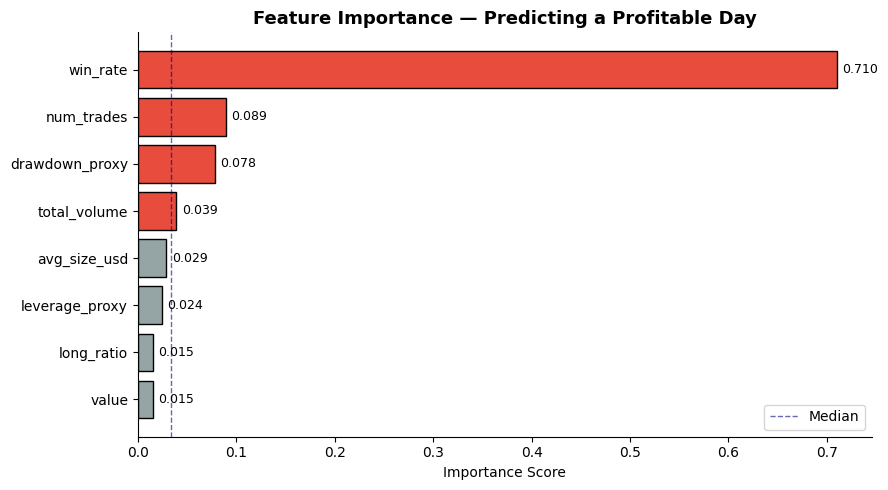

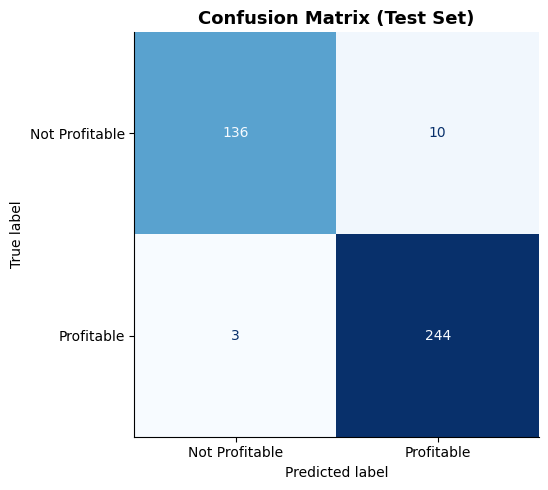

In [ ]:
#Predict whether a trader's day will be profitable

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

FEATURES = ['num_trades', 'avg_size_usd', 'long_ratio', 'total_volume',
            'win_rate', 'drawdown_proxy', 'leverage_proxy', 'value']

model_df = fvg[FEATURES + ['total_pnl']].copy()
model_df['long_ratio'] = model_df['long_ratio'].fillna(0.5)  # neutral fill for days with no directional trades
model_df['target'] = (model_df['total_pnl'] > 0).astype(int)  # 1 = profitable day
model_df = model_df.dropna()

X = model_df[FEATURES]
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class balance in both splits
)

clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# 5-fold cross-validation
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='f1')
print(f"CV F1 scores: {cv_scores.round(3)}")
print(f"Mean CV F1:   {cv_scores.mean():.3f}")
print("\n", classification_report(y_test, clf.predict(X_test)))

#Metric importance chart
import matplotlib.pyplot as plt

importance = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > importance.median() else '#95a5a6' for v in importance.values]
bars = ax.barh(importance.index, importance.values, color=colors, edgecolor='black')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Metric Importance — Predicting a Profitable Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(importance.median(), color='navy', linestyle='--', linewidth=1, alpha=0.6, label='Median')
ax.legend()
plt.tight_layout()
plt.savefig('bonus1_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, clf.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['Not Profitable','Profitable']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bonus2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()